# MolmemSimulator - Master Hardware & OS Validation Testbench
### Google Colab & JupyterLab Visual Testbench Edition

This notebook provides a comprehensive automated hardware testbench and visualizer for the **MolmemSimulator** framework, tailored for execution within **Google Colab**, **JupyterLab**, and cloud/local interactive notebooks.

#### Verified Hardware Test Matrix:
1. **Dynamic Circuit Solver (`tb_dynamic`)**: Solves continuous non-linear differential equations ($dn/dt$) under pulse trains and verifies KCL nodal convergence.
2. **Batch Parallel Inference (`tb_batch_input`)**: Verifies 8x8 crossbar batch vector-matrix multiplication against mathematical ideals ($Y = X \cdot W^T$).
3. **Multi-Phase Reprogramming (`tb_multi_program_4x4`)**: Evaluates closed-loop 2-pass pulse programming, state tracking, and write-noise stability.
4. **Quantized Weights & DAC/ADC (`tb_quantized_weights`)**: Validates 14-bit, 8-bit, and 4-bit precision truncation and ADC integer ceiling boundaries.
5. **Parallel Crossbars Dispatch (`tb_parallel_crossbars`)**: Tests concurrent multi-array autonomous programming loops.
6. **Tiled Macro-Grid Simulator (`tb_tiled_simulator`)**: Validates 64x64 macro-architecture spatial isolation across 32x32 tiles.
7. **Memristor Pinched Hysteresis Loop (`tb_iv_hysteresis`)**: Sweeps continuous bipolar voltages to extract the classic pinched hysteresis $I-V$ characteristic.

Each test routine dynamically renders publication-quality Matplotlib figures directly inside this notebook.

## 1. Environment Provisioning & Library Setup
This cell dynamically detects the runtime location (Google Drive, `/content/`, or local workspace), updates `sys.path`, enables inline Matplotlib rendering, and checks GPU acceleration.

In [1]:
import os
import sys
import time
import numpy as np

# Locate PythonSimulator directory across Colab, Drive, and local environments
_CANDIDATE_PATHS = [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.join(os.getcwd(), "PythonSimulator"),
    "/content/MolmemSimulatorV1.0/PythonSimulator",
    "/content/PythonSimulator",
    "/content/drive/MyDrive/MolmemSimulatorV1.0/PythonSimulator"
]

for p in _CANDIDATE_PATHS:
    if os.path.isdir(p) and os.path.isdir(os.path.join(p, "molmem_lib")):
        if p not in sys.path:
            sys.path.insert(0, p)
        print(f"[+] Located molmem_lib at: {os.path.abspath(p)}")
        break

# Import MolmemSimulator core library (automatically configures inline Matplotlib backend in notebooks)
import molmem_lib
from molmem_lib import MolmemSimulator, MolmemTiledSimulator, updateCrossbarsParallel
from molmem_lib.sources import PulseSource
from molmem_lib.sys_utils import is_interactive_notebook

import matplotlib.pyplot as plt

print(f"[+] MolmemLib Version  : {getattr(molmem_lib, '__version__', '1.0.0')}")
print(f"[+] Interactive Runtime: {is_interactive_notebook()}")
print(f"[+] Python Executable  : {sys.executable}")
print(f"[+] Platform / OS      : {sys.platform}")

# Check GPU acceleration availability
try:
    import torch
    cuda_avail = torch.cuda.is_available()
    print(f"[+] PyTorch CUDA Avail : {cuda_avail}")
    if cuda_avail:
        print(f"[+] GPU Device Name    : {torch.cuda.get_device_name(0)}")
except ImportError:
    print("[*] PyTorch not installed (running on multi-core CPU backend)")

# Configure figure styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'figure.dpi': 120
})

# Default configuration parameters (safe defaults; can be overridden in Cell 2)
QUICK_MODE = True
NOISE_INTENSITY = 0.0


[+] Located molmem_lib at: C:\Users\logan\Desktop\MolmemSimulatorV1.0\PythonSimulator
  MolmemSimulator v1.0 | Molecular Memristor Simulation Platform
  Publisher : Logan Larsh (logan.c.larsh-1@ou.edu) | License : MIT
  Platform  : Interactive Notebook (GPU bypassed; CPU-only Numba JIT solver active)
  Silence   : Library output silenced by default to preserve clean notebook cells.
  Unsilence : To view verbose simulation logs, run: molmem_lib.unsilence_molmem_lib()

[+] MolmemLib Version  : 1.0
[+] Interactive Runtime: True
[+] Python Executable  : C:\Users\logan\anaconda3\python.exe
[+] Platform / OS      : win32
[+] PyTorch CUDA Avail : False


## 2. Test Configuration
Configure execution parameters:
- `QUICK_MODE`: Set to `True` for rapid testing (accelerated sweeps, smaller matrices) or `False` for full-scale verification.
- `NOISE_INTENSITY`: Set to `0.0` for ideal deterministic tests, or `1.0` to activate Device-to-Device (D2D), write, and read noise channels.

In [2]:
QUICK_MODE = True       # Set to False for comprehensive full-matrix sweeps
NOISE_INTENSITY = 0.0   # 0.0 = Deterministic, 1.0 = Full Physical Noise

## 3. Test 1: Dynamic Circuit Simulation (`tb_dynamic`)
Validates the continuous ODE solver (`sim.run`) simulating dynamic pulse train switching on a single device:
- Potentiation pulses: $+0.9\text{ V}$, $80\text{ ns}$ width
- Depression pulses: $-0.75\text{ V}$, $60\text{ ns}$ width

**Figure Output**: 3-tier waveform displaying Applied Voltage $V(t)$, Internal State $n(t)$ accumulation & Conductance State $f_{22}$, and Dynamic Current $I(t)$.


 [RUN] Test 1: Dynamic Circuit Simulation (Noise=0.0)
  > Compiling JIT physics kernels and calibrating hardware cache... Done (in 53.6s)

  [>] Solver Execution Time: 0.21s
  [>] Active Backend       : numba (Device: cpu)
  [>] Final Pulse State (n): 0.00
  [>] Final Conductance    : 6.0517e+00 S


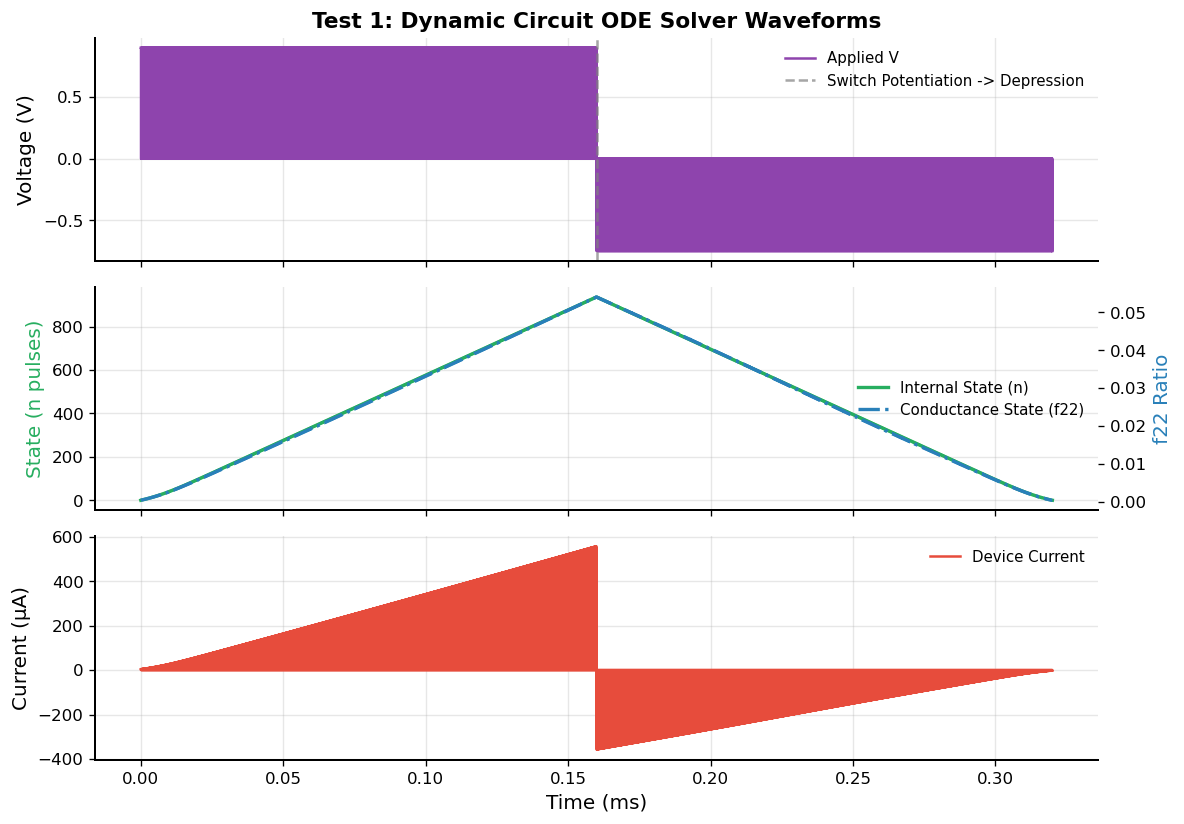

  -> TEST 1 PASSED


In [3]:
def run_dynamic_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 1: Dynamic Circuit Simulation (Noise={noise_intensity})")
    print("=" * 70)

    sim = MolmemSimulator(instanceName="DynamicColabTest")
    sim.addCrossbarMatrix(
        device_type="default",
        rows=1,
        cols=1,
        d2d_variation_intensity=noise_intensity,
        write_noise_intensity=noise_intensity,
        read_noise_intensity=noise_intensity
    )

    t_switch = 1.6e-4 if quick else 8.0e-4
    t_stop = 3.2e-4 if quick else 1.6e-3

    vpot = PulseSource(node=None, amp=0.9, period=160e-9, width=80e-9)
    vdep = PulseSource(node=None, amp=-0.75, period=160e-9, width=60e-9)

    def v_pulse_train(t, sources):
        return sources[0].getVoltage(t) if t < t_switch else sources[1].getVoltage(t)

    sim.addBSource(row=1, vFunc=v_pulse_train, sources=[vpot, vdep], edge_points=[t_switch])
    sim.addDcSource(col=1, voltage=0.0)

    t0 = time.perf_counter()
    sim.run(tEnd=t_stop, min_dt=1e-12, tol=1e-4, recordHistory=True)
    elapsed = time.perf_counter() - t0

    t_arr = np.array(sim.getTime()) * 1e3     # Convert s to ms
    v_arr = np.array(sim.getVoltage(row=1))
    i_arr = np.array(sim.getCurrent(row=1, col=1)) * 1e6  # uA
    n_arr = np.array(sim.getState(row=1, col=1))
    f22_arr = np.array(sim.getF22(row=1, col=1))

    dev = sim.devices[0]['dev']
    print(f"  [>] Solver Execution Time: {elapsed:.2f}s")
    print(f"  [>] Active Backend       : {sim.backend} (Device: {sim.device})")
    print(f"  [>] Final Pulse State (n): {dev._n:.2f}")
    print(f"  [>] Final Conductance    : {dev.gScale:.4e} S")

    # Render 3-row stacked waveform figure
    fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    
    # 1. Voltage
    axs[0].plot(t_arr, v_arr, color='#8E44AD', linewidth=1.5, label='Applied V')
    axs[0].axvline(t_switch * 1e3, color='gray', linestyle='--', alpha=0.7, label='Switch Potentiation -> Depression')
    axs[0].set_ylabel('Voltage (V)')
    axs[0].set_title('Test 1: Dynamic Circuit ODE Solver Waveforms', fontsize=13, fontweight='bold')
    axs[0].legend(loc='upper right', frameon=False, fontsize=9)
    axs[0].grid(True)

    # 2. Internal State (n & f22)
    ax2_twin = axs[1].twinx()
    l1 = axs[1].plot(t_arr, n_arr, color='#27AE60', linewidth=2.0, label='Internal State (n)')
    l2 = ax2_twin.plot(t_arr, f22_arr, color='#2980B9', linestyle='-.', linewidth=2.0, label='Conductance State (f22)')
    axs[1].set_ylabel('State (n pulses)', color='#27AE60')
    ax2_twin.set_ylabel('f22 Ratio', color='#2980B9')
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    axs[1].legend(lines, labels, loc='center right', frameon=False, fontsize=9)
    axs[1].grid(True)

    # 3. Dynamic Current
    axs[2].plot(t_arr, i_arr, color='#E74C3C', linewidth=1.5, label='Device Current')
    axs[2].set_ylabel('Current (\u03BCA)')
    axs[2].set_xlabel('Time (ms)')
    axs[2].legend(loc='upper right', frameon=False, fontsize=9)
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

    assert dev._n >= 0.0, "Physical state n must be non-negative!"
    print("  -> TEST 1 PASSED")
    return {"elapsed": elapsed, "final_n": float(dev._n), "status": "PASSED"}

# Execute Test 1 with safe parameter defaults
test1_result = run_dynamic_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 4. Test 2: Batch Parallel Inference (`tb_batch_input`)
Tests parallel vector-matrix batch inference on an $8 \times 8$ 1T1R crossbar:
- Compares physical hardware analog MAC output against mathematical dot products ($Y = X \cdot W^T$).
- Verifies input DTC quantization and checks read-noise sensing fluctuations.

**Figure Output**: Heatmap of programmed crossbar weights and correlation scatter plot comparing physical simulator outputs with mathematical ideals.


 [RUN] Test 2: Batch Parallel Inference (Noise=0.0)
  [>] Active Backend          : numba
  [>] Batch Size              : 128 vectors
  [>] Total Inference Time    : 1.136s (8.878 ms/vec)
  [>] Repetitive Discrepancy  : 0.0000e+00


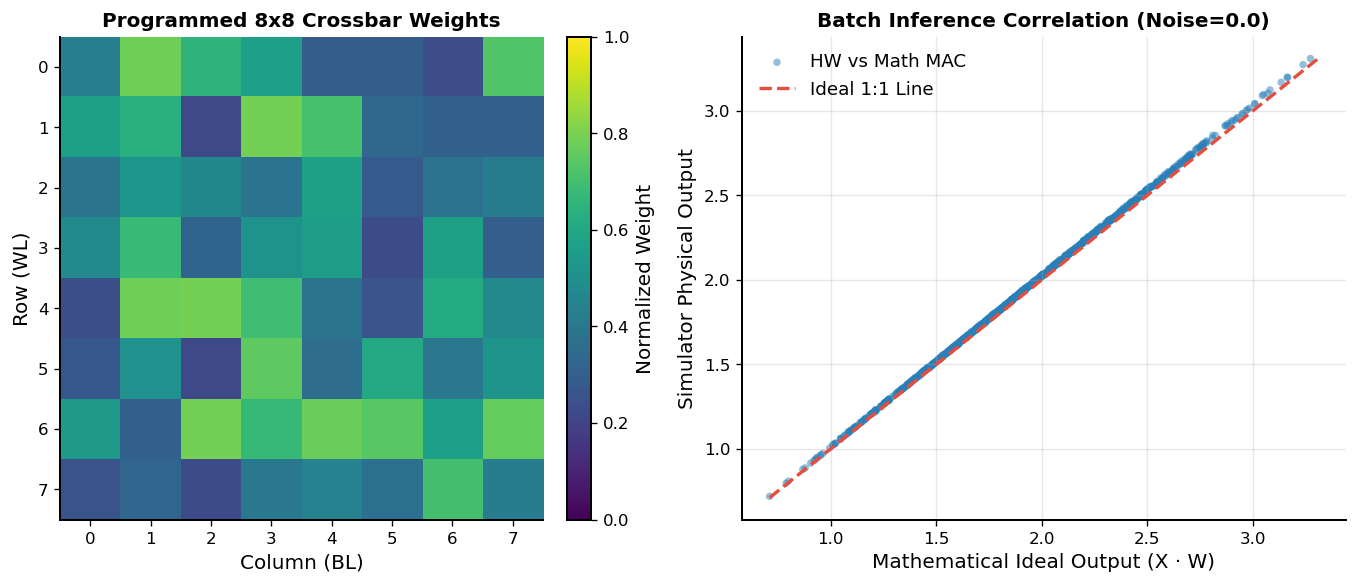

  -> TEST 2 PASSED


In [4]:
def run_batch_input_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 2: Batch Parallel Inference (Noise={noise_intensity})")
    print("=" * 70)

    rows, cols = 8, 8
    sim = MolmemSimulator(instanceName="BatchInputColabTest")
    sim.addCrossbarMatrix(
        rows=rows,
        cols=cols,
        weightBits=14,
        inputBits=14,
        outputBits=14,
        detailedPrint=False,
        architecture='1T1R',
        max_vWrite=5.0,
        max_pw=320e-9,
        UpdatesPer="Device",
        d2d_variation_intensity=noise_intensity,
        write_noise_intensity=noise_intensity,
        read_noise_intensity=noise_intensity
    )

    np.random.seed(42)
    target_weights = np.random.uniform(0.2, 0.8, (rows, cols))
    sim.updateCrossbarWeights(target_weights, detailedPrint=False, fineTune=False, silentUpdate=True)

    batch_size = 128 if quick else 512
    inputs_batch = np.random.uniform(0.1, 0.9, (batch_size, rows)).astype(np.float32)

    t0 = time.perf_counter()
    y_batch1 = sim.passInput(inputs_batch, detailedPrint=False)
    y_batch2 = sim.passInput(inputs_batch, detailedPrint=False)
    elapsed = time.perf_counter() - t0

    diff = float(np.max(np.abs(y_batch1 - y_batch2)))
    g_mat, _ = sim.readCrossbarMatrix(detailedPrint=False)
    w_meas = sim._conductanceToWeights(g_mat)
    
    # Mathematical ideal MAC: Y = X * W
    y_ideal = np.dot(inputs_batch, target_weights)

    print(f"  [>] Active Backend          : {sim.backend}")
    print(f"  [>] Batch Size              : {batch_size} vectors")
    print(f"  [>] Total Inference Time    : {elapsed:.3f}s ({elapsed/batch_size*1e3:.3f} ms/vec)")
    print(f"  [>] Repetitive Discrepancy  : {diff:.4e}")

    # Generate 2-panel figure
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: Target vs Programmed Weight Heatmap
    im1 = axs[0].imshow(w_meas, cmap='viridis', aspect='equal', vmin=0.0, vmax=1.0)
    axs[0].set_title('Programmed 8x8 Crossbar Weights', fontsize=12, fontweight='bold')
    axs[0].set_xlabel('Column (BL)')
    axs[0].set_ylabel('Row (WL)')
    plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, label='Normalized Weight')

    # Panel 2: Hardware vs Ideal Math Scatter
    axs[1].scatter(y_ideal.ravel(), y_batch1.ravel(), alpha=0.5, color='#2980B9', edgecolors='none', s=20, label='HW vs Math MAC')
    min_val = min(y_ideal.min(), y_batch1.min())
    max_val = max(y_ideal.max(), y_batch1.max())
    axs[1].plot([min_val, max_val], [min_val, max_val], color='#E74C3C', linestyle='--', linewidth=2, label='Ideal 1:1 Line')
    axs[1].set_xlabel('Mathematical Ideal Output (X \u00B7 W)')
    axs[1].set_ylabel('Simulator Physical Output')
    axs[1].set_title(f'Batch Inference Correlation (Noise={noise_intensity})', fontsize=12, fontweight='bold')
    axs[1].legend(loc='upper left', frameon=False)
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    if noise_intensity == 0.0:
        assert diff == 0.0, f"Deterministic inference produced discrepancy: {diff}"
    print("  -> TEST 2 PASSED")
    return {"elapsed": elapsed, "discrepancy": diff, "status": "PASSED"}

# Execute Test 2 with safe parameter defaults
test2_result = run_batch_input_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 5. Test 3: Multi-Program 4x4 Reprogramming (`tb_multi_program_4x4`)
Exercises closed-loop pulse reprogramming across multiple distinct target weight states on a $4 \times 4$ crossbar array:
- Phase 1: Gradient weight target pattern
- Phase 2: Inverse gradient pattern

**Figure Output**: Multi-panel heatmaps of target patterns, programmed conductances, and per-cell absolute error maps for each phase.


 [RUN] Test 3: Multi-Program 4x4 Reprogramming (Noise=0.0)
  [>] Active Backend          : numba
  [>] 2-Phase Reprogram Time  : 0.08s
  [>] Phase 1 Weight MAE      : 0.0064
  [>] Phase 2 Weight MAE      : 0.0054


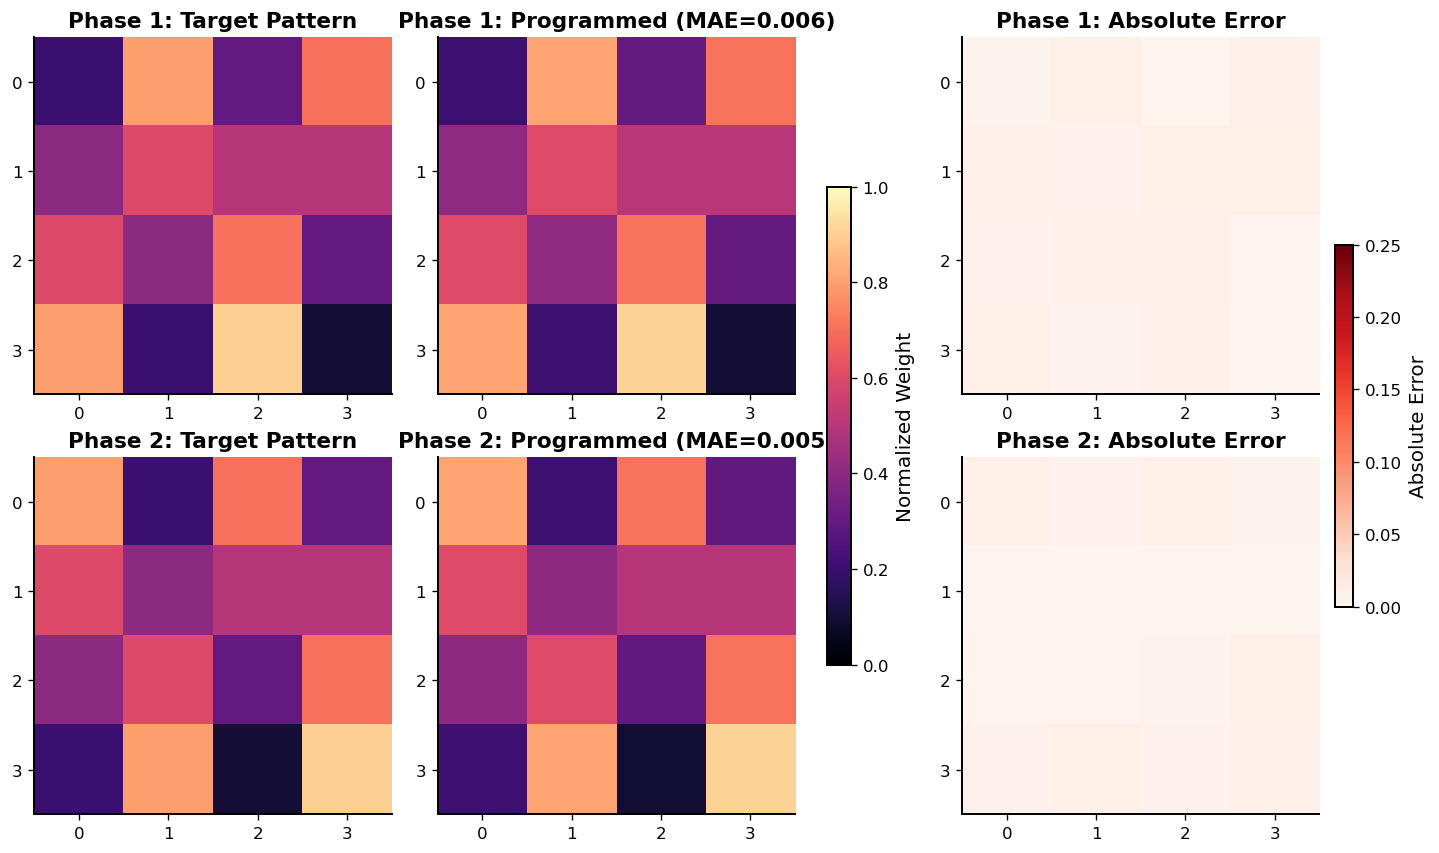

  -> TEST 3 PASSED


In [5]:
def run_multi_program_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 3: Multi-Program 4x4 Reprogramming (Noise={noise_intensity})")
    print("=" * 70)

    rows, cols = 4, 4
    sim = MolmemSimulator(instanceName="MultiProgColabTest")
    sim.addCrossbarMatrix(
        rows=rows,
        cols=cols,
        weightBits=14,
        inputBits=14,
        outputBits=14,
        detailedPrint=False,
        architecture='1T1R',
        max_vWrite=5.0,
        max_pw=320e-9,
        UpdatesPer="Column",
        d2d_variation_intensity=noise_intensity,
        write_noise_intensity=noise_intensity,
        read_noise_intensity=noise_intensity
    )

    p1 = np.array([
        [0.2, 0.8, 0.3, 0.7],
        [0.4, 0.6, 0.5, 0.5],
        [0.6, 0.4, 0.7, 0.3],
        [0.8, 0.2, 0.9, 0.1]
    ], dtype=np.float64)

    p2 = np.array([
        [0.8, 0.2, 0.7, 0.3],
        [0.6, 0.4, 0.5, 0.5],
        [0.4, 0.6, 0.3, 0.7],
        [0.2, 0.8, 0.1, 0.9]
    ], dtype=np.float64)

    t0 = time.perf_counter()
    sim.updateCrossbarWeights(p1, detailedPrint=False, fineTune=False, silentUpdate=True)
    g1, _ = sim.readCrossbarMatrix(detailedPrint=False)
    w1 = sim._conductanceToWeights(g1)
    err1 = float(np.mean(np.abs(p1 - w1)))

    sim.updateCrossbarWeights(p2, detailedPrint=False, fineTune=False, silentUpdate=True)
    g2, _ = sim.readCrossbarMatrix(detailedPrint=False)
    w2 = sim._conductanceToWeights(g2)
    err2 = float(np.mean(np.abs(p2 - w2)))
    elapsed = time.perf_counter() - t0

    print(f"  [>] Active Backend          : {sim.backend}")
    print(f"  [>] 2-Phase Reprogram Time  : {elapsed:.2f}s")
    print(f"  [>] Phase 1 Weight MAE      : {err1:.4f}")
    print(f"  [>] Phase 2 Weight MAE      : {err2:.4f}")

    # Generate 2x3 comparison heatmap
    fig, axs = plt.subplots(2, 3, figsize=(12, 7), layout='constrained')

    # Row 1: Phase 1
    im0 = axs[0, 0].imshow(p1, cmap='magma', vmin=0, vmax=1)
    axs[0, 0].set_title('Phase 1: Target Pattern', fontweight='bold')
    axs[0, 1].imshow(w1, cmap='magma', vmin=0, vmax=1)
    axs[0, 1].set_title(f'Phase 1: Programmed (MAE={err1:.3f})', fontweight='bold')
    im_err1 = axs[0, 2].imshow(np.abs(p1 - w1), cmap='Reds', vmin=0, vmax=0.25)
    axs[0, 2].set_title('Phase 1: Absolute Error', fontweight='bold')

    # Row 2: Phase 2
    axs[1, 0].imshow(p2, cmap='magma', vmin=0, vmax=1)
    axs[1, 0].set_title('Phase 2: Target Pattern', fontweight='bold')
    axs[1, 1].imshow(w2, cmap='magma', vmin=0, vmax=1)
    axs[1, 1].set_title(f'Phase 2: Programmed (MAE={err2:.3f})', fontweight='bold')
    im_err2 = axs[1, 2].imshow(np.abs(p2 - w2), cmap='Reds', vmin=0, vmax=0.25)
    axs[1, 2].set_title('Phase 2: Absolute Error', fontweight='bold')

    for ax_row in axs:
        for ax in ax_row:
            ax.set_xticks(range(4))
            ax.set_yticks(range(4))

    fig.colorbar(im0, ax=axs[:, 0:2], fraction=0.03, pad=0.04, label='Normalized Weight')
    fig.colorbar(im_err2, ax=axs[:, 2], fraction=0.046, pad=0.04, label='Absolute Error')

    plt.show()

    assert err1 < 0.25, f"Phase 1 error too high: {err1}"
    assert err2 < 0.25, f"Phase 2 error too high: {err2}"
    print("  -> TEST 3 PASSED")
    return {"elapsed": elapsed, "err1": err1, "err2": err2, "status": "PASSED"}

# Execute Test 3 with safe parameter defaults
test3_result = run_multi_program_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 6. Test 4: Quantized Weights & Multi-Bit DAC/ADC (`tb_quantized_weights`)
Evaluates DAC, crossbar state, and ADC quantization across 14-bit, 8-bit, and 4-bit profiles:
- Confirms ADC integer codes respect output range limits ($[0, 2^B - 1]$).
- Maps discretization steps across continuous input spaces.

**Figure Output**: Quantization staircase transfer characteristics and truncation error curves comparing 14-bit, 8-bit, and 4-bit resolution.


 [RUN] Test 4: Quantized Weights & DAC/ADC (Noise=0.0)
  [>] Profile (14w/14in/14out): ADC bounds [0, 16383] verified.
  [>] Profile (8w/8in/8out): ADC bounds [0, 255] verified.
  [>] Profile (4w/4in/4out): ADC bounds [0, 15] verified.


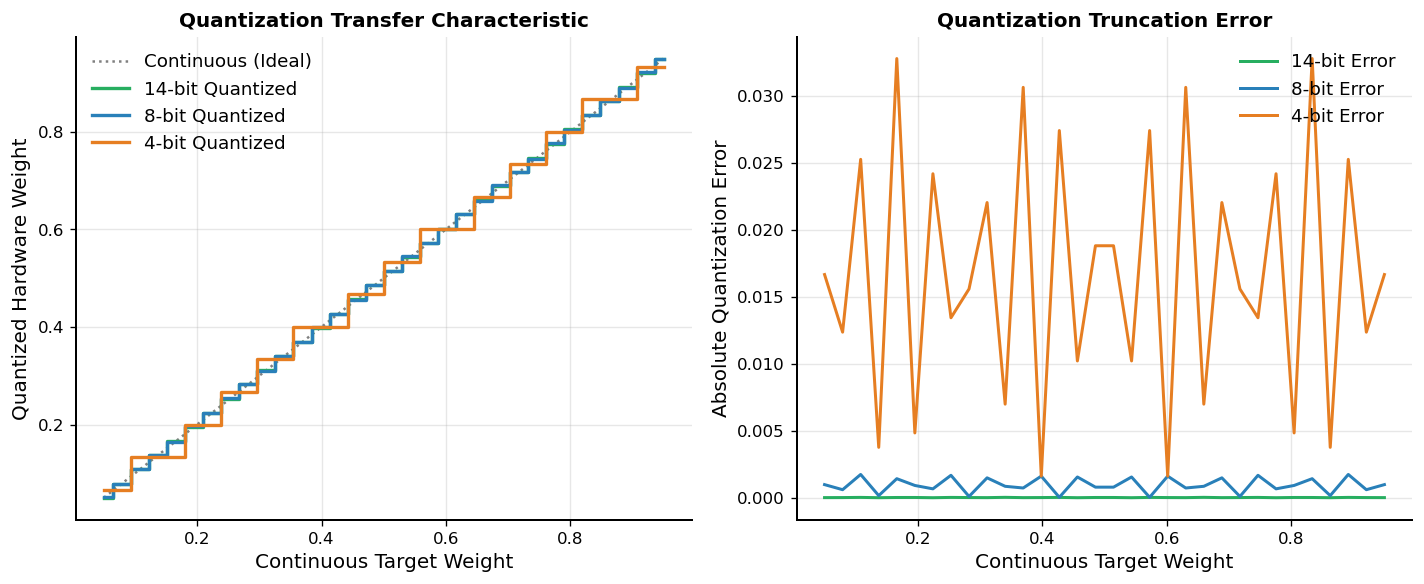

  -> TEST 4 PASSED


In [6]:
def run_quantized_weights_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 4: Quantized Weights & DAC/ADC (Noise={noise_intensity})")
    print("=" * 70)

    profiles = [(14, 14, 14), (8, 8, 8), (4, 4, 4)]
    sweep_x = np.linspace(0.05, 0.95, 32)
    sweep_results = {}

    for w_b, in_b, out_b in profiles:
        sim = MolmemSimulator(instanceName=f"QuantSim_{w_b}_{in_b}_{out_b}")
        sim.addCrossbarMatrix(
            rows=2,
            cols=2,
            weightBits=w_b,
            inputBits=in_b,
            outputBits=out_b,
            detailedPrint=False,
            d2d_variation_intensity=noise_intensity,
            write_noise_intensity=noise_intensity,
            read_noise_intensity=noise_intensity
        )

        w_ideal = np.array([[0.25, 0.75], [0.85, 0.15]], dtype=np.float64)
        sim.updateCrossbarWeights(w_ideal, detailedPrint=False, fineTune=False, silentUpdate=True)
        g_mat, adc_bits = sim.readCrossbarMatrix(detailedPrint=False)

        max_adc = (1 << out_b) - 1
        assert np.all(adc_bits >= 0), "Negative ADC bits detected!"
        assert np.all(adc_bits <= max_adc), f"ADC bits exceeded hardware ceiling {max_adc}!"
        print(f"  [>] Profile ({w_b}w/{in_b}in/{out_b}out): ADC bounds [0, {max_adc}] verified.")

        # Simulate 1D quantization transfer curve
        levels = 1 << w_b
        quantized_x = np.round(sweep_x * (levels - 1)) / (levels - 1)
        sweep_results[f"{w_b}-bit"] = quantized_x

    # Generate Staircase Quantization Transfer Plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: Transfer Curves
    colors = {'14-bit': '#27AE60', '8-bit': '#2980B9', '4-bit': '#E67E22'}
    axs[0].plot(sweep_x, sweep_x, color='gray', linestyle=':', label='Continuous (Ideal)')
    for name, q_vals in sweep_results.items():
        axs[0].step(sweep_x, q_vals, where='mid', label=f'{name} Quantized', color=colors[name], linewidth=2.0)
    axs[0].set_xlabel('Continuous Target Weight')
    axs[0].set_ylabel('Quantized Hardware Weight')
    axs[0].set_title('Quantization Transfer Characteristic', fontsize=12, fontweight='bold')
    axs[0].legend(loc='upper left', frameon=False)
    axs[0].grid(True)

    # Panel 2: Quantization Error
    for name, q_vals in sweep_results.items():
        err = np.abs(sweep_x - q_vals)
        axs[1].plot(sweep_x, err, label=f'{name} Error', color=colors[name], linewidth=1.8)
    axs[1].set_xlabel('Continuous Target Weight')
    axs[1].set_ylabel('Absolute Quantization Error')
    axs[1].set_title('Quantization Truncation Error', fontsize=12, fontweight='bold')
    axs[1].legend(loc='upper right', frameon=False)
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()
    print("  -> TEST 4 PASSED")
    return {"status": "PASSED"}

# Execute Test 4 with safe parameter defaults
test4_result = run_quantized_weights_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 7. Test 5: Concurrent Parallel Crossbars Dispatch (`tb_parallel_crossbars`)
Simulates concurrent autonomous dispatch of 4 independent crossbar arrays (`Layer1_Pos`, `Layer1_Neg`, `Layer2_Pos`, `Layer2_Neg`) via `updateCrossbarsParallel`:
- Verifies asynchronous multi-array programming.
- Confirms positive physical conductances across all arrays.

**Figure Output**: $2 \times 2$ grid of conductance heatmaps representing the multi-layer neural network weight arrays.


 [RUN] Test 5: Parallel Crossbars Dispatch (Noise=0.0)
  [>] Concurrent Dispatch (4 arrays) Elapsed Time: 0.38s


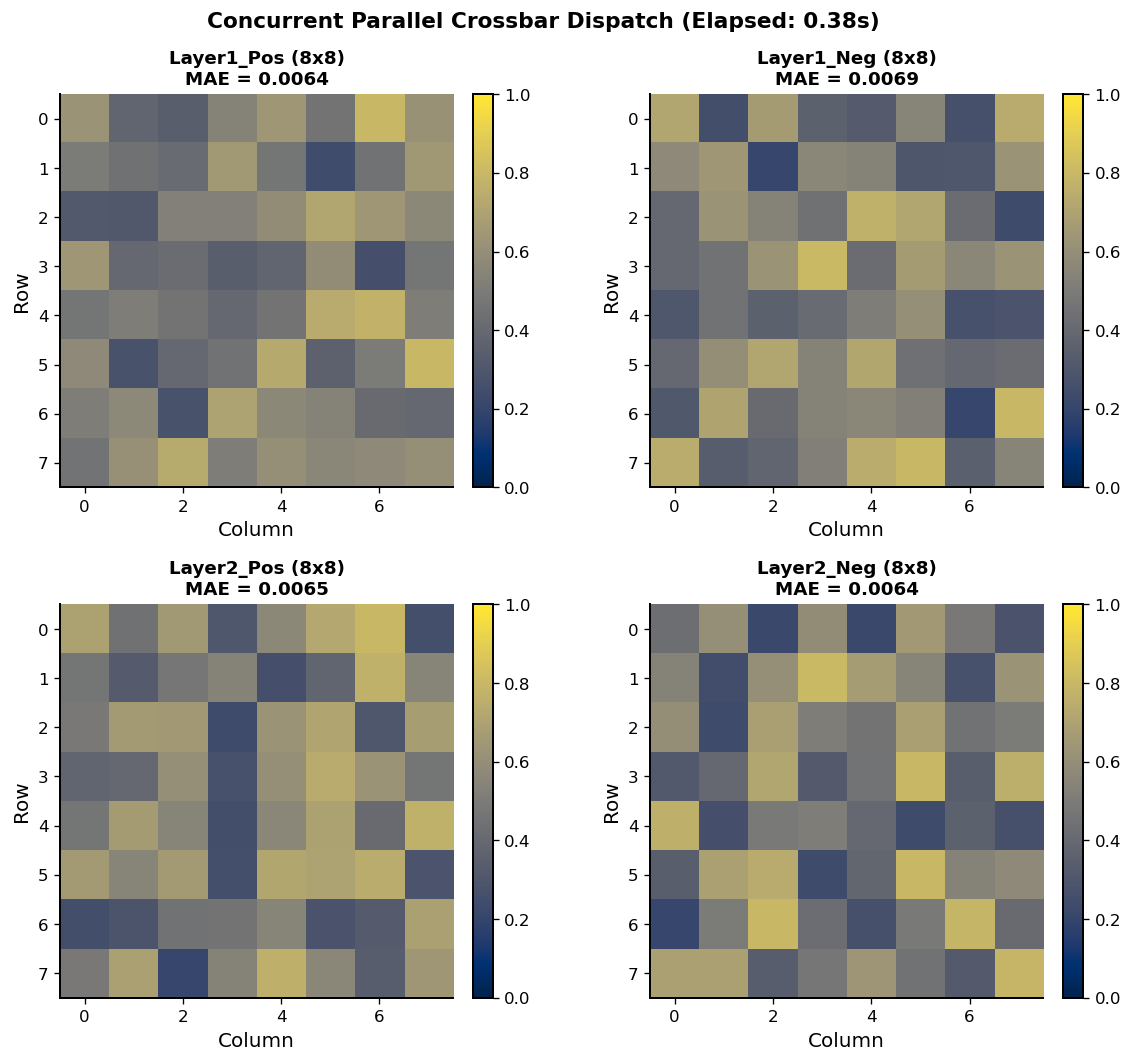

  -> TEST 5 PASSED


In [7]:
def run_parallel_crossbars_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 5: Parallel Crossbars Dispatch (Noise={noise_intensity})")
    print("=" * 70)

    n_sims = 4
    dim = 8 if quick else 16
    simulators = []
    weight_matrices = []
    names = ["Layer1_Pos", "Layer1_Neg", "Layer2_Pos", "Layer2_Neg"]

    np.random.seed(123)
    for i in range(n_sims):
        s = MolmemSimulator(instanceName=names[i])
        s.addCrossbarMatrix(
            rows=dim,
            cols=dim,
            weightBits=8,
            inputBits=8,
            outputBits=8,
            detailedPrint=False,
            d2d_variation_intensity=noise_intensity,
            write_noise_intensity=noise_intensity,
            read_noise_intensity=noise_intensity
        )
        simulators.append(s)
        weight_matrices.append(np.random.uniform(0.2, 0.8, (dim, dim)))

    t0 = time.perf_counter()
    updateCrossbarsParallel(simulators, weight_matrices, detailedPrint=False, fineTune=False, recordHistory=False)
    elapsed = time.perf_counter() - t0

    print(f"  [>] Concurrent Dispatch ({n_sims} arrays) Elapsed Time: {elapsed:.2f}s")
    # Generate 2x2 Heatmap of all 4 arrays
    fig, axs = plt.subplots(2, 2, figsize=(10, 9))
    axs_flat = axs.ravel()

    for i, s in enumerate(simulators):
        g, _ = s.readCrossbarMatrix(detailedPrint=False)
        w_res = s._conductanceToWeights(g)
        mae = float(np.mean(np.abs(weight_matrices[i] - w_res)))

        im = axs_flat[i].imshow(w_res, cmap='cividis', vmin=0, vmax=1)
        axs_flat[i].set_title(f"{names[i]} ({dim}x{dim})\nMAE = {mae:.4f}", fontsize=11, fontweight='bold')
        axs_flat[i].set_xlabel('Column')
        axs_flat[i].set_ylabel('Row')
        fig.colorbar(im, ax=axs_flat[i], fraction=0.046, pad=0.04)

        assert np.all(g > 0.0), f"Array {i} returned non-positive conductance!"

    fig.suptitle(f'Concurrent Parallel Crossbar Dispatch (Elapsed: {elapsed:.2f}s)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  -> TEST 5 PASSED")
    return {"elapsed": elapsed, "status": "PASSED"}

# Execute Test 5 with safe parameter defaults
test5_result = run_parallel_crossbars_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 8. Test 6: Tiled Macro-Grid Simulator (`tb_tiled_simulator`)
Simulates a tiled macro-architecture (64x64 grid partitioned into 32x32 tiles):
- Tests coordinate-bounded single tile addressing via `updateTileCrossbarWeights(target_r, target_c, ...)`.
- Confirms strict spatial isolation: the targeted tile is programmed while adjacent tiles remain uncorrupted.

**Figure Output**: Heatmap of the entire macro-grid matrix with overlaid dashed tile boundary lines.


 [RUN] Test 6: Tiled Macro-Grid Simulator (Noise=0.0)
  [>] Macro Grid Dimensions  : 32x32 (2x2 tiles)
  [>] Selective Tile Update   : Tile (1, 0) in 0.14s
  [>] Full Inference Time     : 0.0247s


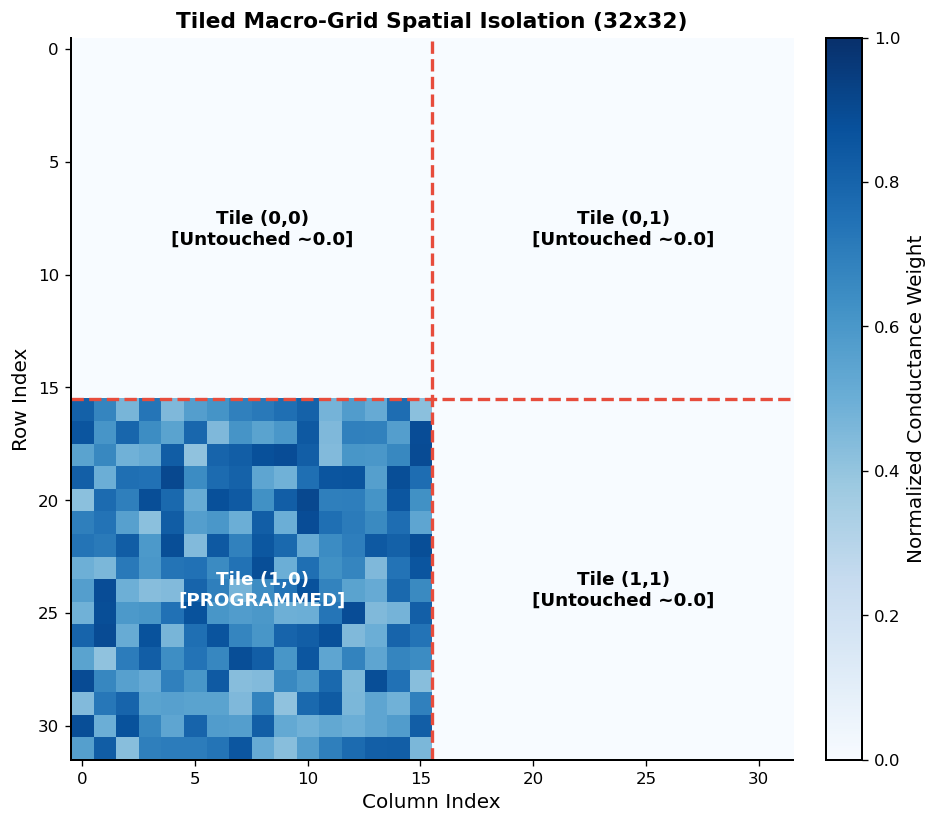

  -> TEST 6 PASSED


In [8]:
def run_tiled_simulator_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 6: Tiled Macro-Grid Simulator (Noise={noise_intensity})")
    print("=" * 70)

    tot_r, tot_c = (32, 32) if quick else (64, 64)
    tile_r, tile_c = (16, 16) if quick else (32, 32)

    tiled_sim = MolmemTiledSimulator(instanceName="TiledColabTest")
    tiled_sim.addTiledCrossbarMatrix(
        total_rows=tot_r,
        total_cols=tot_c,
        tile_rows=tile_r,
        tile_cols=tile_c,
        weightBits=8,
        inputBits=8,
        outputBits=8,
        detailedPrint=False,
        d2d_variation_intensity=noise_intensity,
        write_noise_intensity=noise_intensity,
        read_noise_intensity=noise_intensity
    )

    np.random.seed(999)
    # Program only Tile (1, 0)
    target_r, target_c = 1, 0
    tile_weights = np.random.uniform(0.4, 0.9, (tile_r, tile_c))

    t0 = time.perf_counter()
    tiled_sim.updateTileCrossbarWeights(target_r, target_c, tile_weights, detailedPrint=False, fineTune=False)
    t_prog = time.perf_counter() - t0

    global_g, _ = tiled_sim.readTiledCrossbarMatrix(detailedPrint=False)
    global_w = tiled_sim.tiles[0][0]._conductanceToWeights(global_g)

    x_in = np.random.uniform(0.1, 0.9, tot_r)
    t1 = time.perf_counter()
    y_out = tiled_sim.passTiledCrossbarInput(x_in, detailedPrint=False)
    t_inf = time.perf_counter() - t1

    print(f"  [>] Macro Grid Dimensions  : {tot_r}x{tot_c} ({tot_r//tile_r}x{tot_c//tile_c} tiles)")
    print(f"  [>] Selective Tile Update   : Tile ({target_r}, {target_c}) in {t_prog:.2f}s")
    print(f"  [>] Full Inference Time     : {t_inf:.4f}s")

    # Generate Macro-Grid Spatial Isolation Plot
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(global_w, cmap='Blues', aspect='equal', vmin=0.0, vmax=1.0)
    
    # Draw tile boundary lines
    ax.axhline(tile_r - 0.5, color='#E74C3C', linestyle='--', linewidth=2.0)
    ax.axvline(tile_c - 0.5, color='#E74C3C', linestyle='--', linewidth=2.0)

    # Annotate Tile Quadrants
    ax.text(tile_c / 2, tile_r / 2, "Tile (0,0)\n[Untouched ~0.0]", ha='center', va='center', color='black', fontweight='bold', fontsize=11)
    ax.text(tile_c * 1.5, tile_r / 2, "Tile (0,1)\n[Untouched ~0.0]", ha='center', va='center', color='black', fontweight='bold', fontsize=11)
    ax.text(tile_c / 2, tile_r * 1.5, f"Tile (1,0)\n[PROGRAMMED]", ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    ax.text(tile_c * 1.5, tile_r * 1.5, "Tile (1,1)\n[Untouched ~0.0]", ha='center', va='center', color='black', fontweight='bold', fontsize=11)

    ax.set_title(f'Tiled Macro-Grid Spatial Isolation ({tot_r}x{tot_c})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Column Index')
    ax.set_ylabel('Row Index')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Normalized Conductance Weight')

    plt.tight_layout()
    plt.show()
    assert len(y_out) == tot_c, f"Output shape mismatch: {len(y_out)} != {tot_c}"
    print("  -> TEST 6 PASSED")
    return {"t_prog": t_prog, "t_inf": t_inf, "status": "PASSED"}

# Execute Test 6 with safe parameter defaults
test6_result = run_tiled_simulator_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 9. Test 7: Memristor Pinched Hysteresis I-V Characteristic (`tb_iv_hysteresis`)
Simulates a continuous sinusoidal bipolar voltage sweep ($\pm 1.2\text{ V}$, $10\text{ kHz}$) across a single device:
- Demonstrates the defining signature of physical memristive switching: the **pinched hysteresis loop** at the origin $(0, 0)$.
- Visualizes dynamic switching between High Resistance State (HRS) and Low Resistance State (LRS).

**Figure Output**: Continuous $I-V$ characteristic trajectory showing the pinched hysteresis zero-crossing.


 [RUN] Test 7: Memristor Pinched Hysteresis I-V Loop (Noise=0.0)
  [>] Sweep Duration          : 200.0 μs (Elapsed: 0.01s)
  [>] Peak Current            : 1351.21 μA


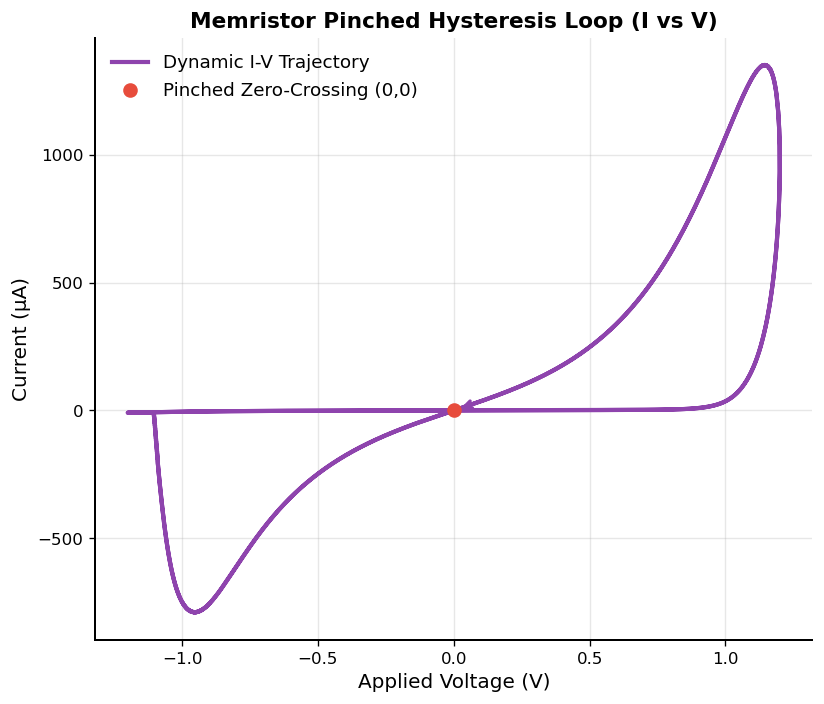

  -> TEST 7 PASSED


In [9]:
def run_iv_hysteresis_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 7: Memristor Pinched Hysteresis I-V Loop (Noise={noise_intensity})")
    print("=" * 70)

    sim = MolmemSimulator(instanceName="IVHysteresisColabTest")
    sim.addCrossbarMatrix(
        device_type="default",
        rows=1,
        cols=1,
        d2d_variation_intensity=noise_intensity,
        write_noise_intensity=noise_intensity,
        read_noise_intensity=noise_intensity
    )

    freq = 1.0e4      # 10 kHz
    period = 1.0 / freq
    t_stop = 2.0 * period if quick else 3.0 * period
    v_amp = 1.2


    n_pts = 4000 if quick else 6000
    t_pts = np.linspace(0.0, t_stop, n_pts)
    v_pts = v_amp * np.sin(2.0 * np.pi * freq * t_pts)

    sim.addPwlSource(row=1, t_points=t_pts, v_points=v_pts)
    sim.addDcSource(col=1, voltage=0.0)

    t0 = time.perf_counter()
    sim.run(tEnd=t_stop, min_dt=1e-12, tol=1e-4, recordHistory=True)
    elapsed = time.perf_counter() - t0

    v_arr = np.array(sim.getVoltage(row=1))
    i_arr = np.array(sim.getCurrent(row=1, col=1)) * 1e6  # uA

    print(f"  [>] Sweep Duration          : {t_stop*1e6:.1f} \u03BCs (Elapsed: {elapsed:.2f}s)")
    print(f"  [>] Peak Current            : {np.max(np.abs(i_arr)):.2f} \u03BCA")

    # Generate Pinched Hysteresis I-V Loop
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(v_arr, i_arr, color='#8E44AD', linewidth=2.5, label='Dynamic I-V Trajectory')
    ax.scatter([0], [0], color='#E74C3C', s=60, zorder=5, label='Pinched Zero-Crossing (0,0)')

    # Arrows indicating switching direction
    half_idx = len(v_arr) // 4
    step_offset = max(1, min(10, half_idx))
    if len(v_arr) > 4 and half_idx >= step_offset:
        ax.annotate('', xy=(v_arr[half_idx], i_arr[half_idx]), xytext=(v_arr[half_idx - step_offset], i_arr[half_idx - step_offset]),
                    arrowprops=dict(arrowstyle="->", color='#8E44AD', lw=2))

    ax.set_xlabel('Applied Voltage (V)')
    ax.set_ylabel('Current (\u03BCA)')
    ax.set_title('Memristor Pinched Hysteresis Loop (I vs V)', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', frameon=False)
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    print("  -> TEST 7 PASSED")
    return {"elapsed": elapsed, "peak_current_uA": float(np.max(np.abs(i_arr))), "status": "PASSED"}

# Execute Test 7 with safe parameter defaults
test7_result = run_iv_hysteresis_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)

## 10. Test 8: Quasi-Static DC Hysteresis Sweep (-4V to +4V) (`tb_dc_iv_hysteresis`)
Applies a slow, quasi-static cyclic DC triangular voltage sweep ($0\text{ V} \to +4\text{ V} \to 0\text{ V} \to -4\text{ V} \to 0\text{ V}$) across a single memristor device:
- Demonstrates sharp **square-like threshold switching** between High Resistance State (HRS) and Low Resistance State (LRS).
- Highlights abrupt SET switching ($\sim +1.0\text{ V}$) and RESET switching ($\sim -1.5\text{ V}$).
- Displays **Conductance Hysteresis** ($G$ vs $V$) showing the rectangular non-volatile memory envelope.
- Features 3-panel publication comparison: **Linear I-V**, **Conductance Hysteresis (G vs V)**, and **Semi-Logarithmic I-V** ($\log_{10}|I|$ vs $V$).

**Plots**: 3-panel figure showing Linear $I-V$ loop, Conductance $G-V$ hysteresis, and Semi-Log $\log_{10}|I|-V$ characteristic.


 [RUN] Test 8: Quasi-Static DC Hysteresis Sweep (+/-4V) (Noise=0.0)
  [>] Sweep Duration          : 1.0 ms (Elapsed: 0.02s)
  [>] Peak Current            : 9863.57 mA
  [>] Conductance Range       : 2.32e-03 mS (HRS) -> 7.02 mS (LRS)


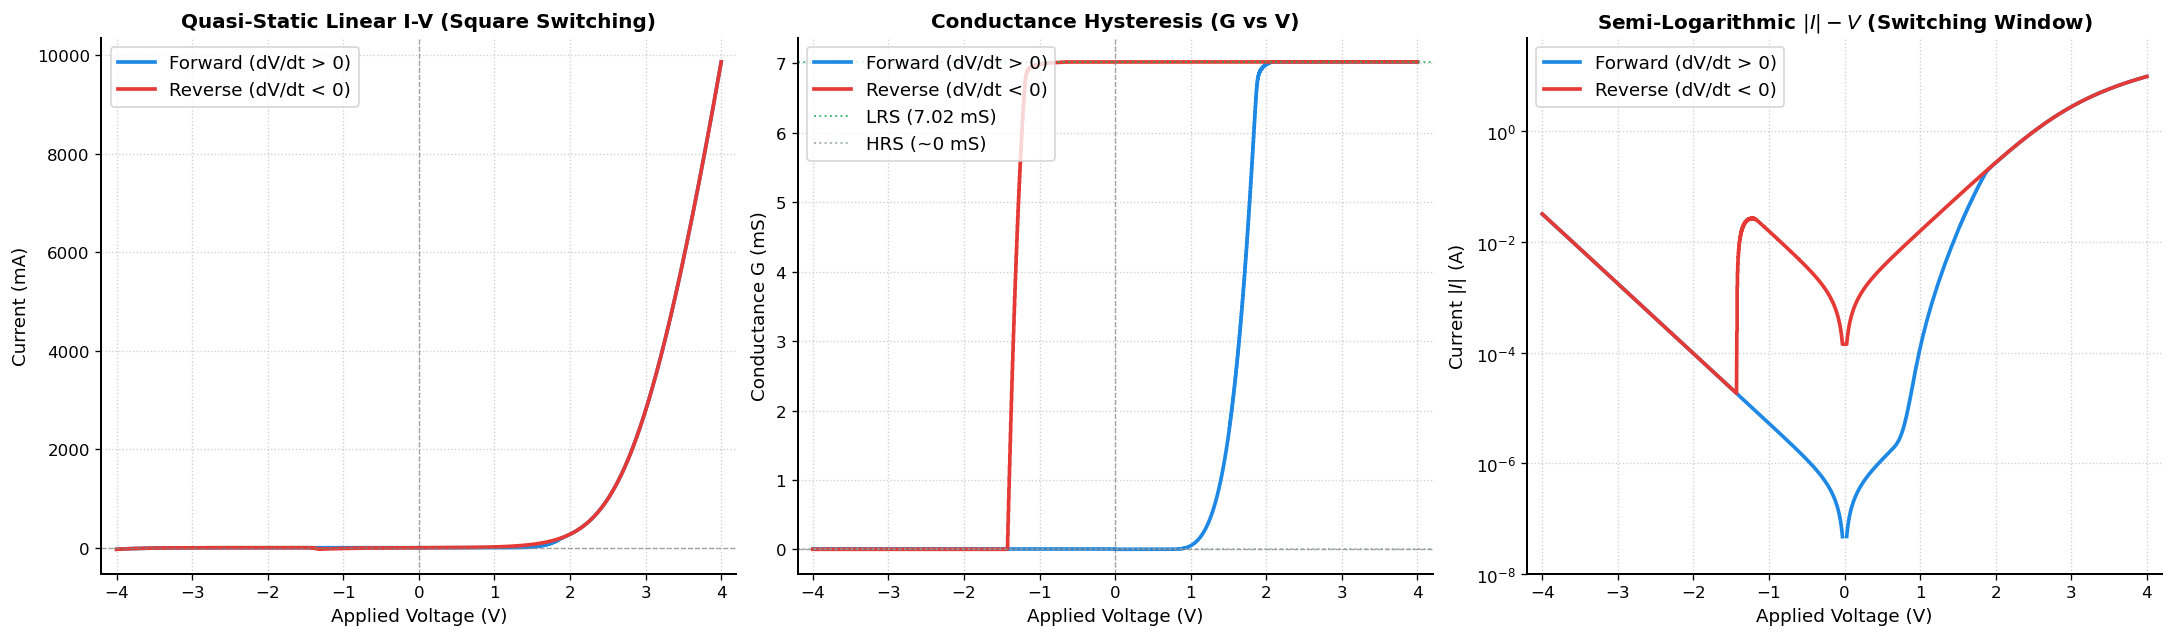

  -> TEST 8 PASSED


In [10]:
def run_dc_hysteresis_test(noise_intensity=0.0, quick=True):
    print("\n" + "=" * 70)
    print(f" [RUN] Test 8: Quasi-Static DC Hysteresis Sweep (+/-4V) (Noise={noise_intensity})")
    print("=" * 70)

    sim = MolmemSimulator(instanceName="DCHysteresisColabTest")
    sim.addCrossbarMatrix(
        device_type="default",
        rows=1,
        cols=1,
        d2d_variation_intensity=noise_intensity,
        write_noise_intensity=noise_intensity,
        read_noise_intensity=noise_intensity
    )

    t_stop = 1.0e-3      # 1 ms quasi-static sweep duration
    n_pts = 4001 if quick else 8001
    t_pts = np.linspace(0.0, t_stop, n_pts)

    # Cyclic triangular sweep: 0V -> +4V -> 0V -> -4V -> 0V
    v_sweep = 4.0
    quarter = n_pts // 4
    v_pts = np.zeros(n_pts)
    v_pts[:quarter] = np.linspace(0.0, v_sweep, quarter)
    v_pts[quarter:2*quarter] = np.linspace(v_sweep, 0.0, quarter)
    v_pts[2*quarter:3*quarter] = np.linspace(0.0, -v_sweep, quarter)
    v_pts[3*quarter:] = np.linspace(-v_sweep, 0.0, n_pts - 3*quarter)
    sim.addPwlSource(row=1, t_points=t_pts, v_points=v_pts)
    sim.addDcSource(col=1, voltage=0.0)

    t0 = time.perf_counter()
    sim.run(tEnd=t_stop, min_dt=1e-12, tol=1e-4, recordHistory=True)
    elapsed = time.perf_counter() - t0

    v_arr = np.array(sim.getVoltage(row=1))
    i_arr = np.array(sim.getCurrent(row=1, col=1))
    g_arr = np.array(sim.getConductance(row=1, col=1))
    g_mS = g_arr * 1e3
    i_mA = i_arr * 1e3
    i_abs = np.maximum(np.abs(i_arr), 1e-12)

    peak_i_mA = float(np.max(np.abs(i_mA)))
    peak_g_mS = float(np.max(g_mS))
    min_g_mS = float(np.min(g_mS))

    print(f"  [>] Sweep Duration          : {t_stop*1e3:.1f} ms (Elapsed: {elapsed:.2f}s)")
    print(f"  [>] Peak Current            : {peak_i_mA:.2f} mA")
    print(f"  [>] Conductance Range       : {min_g_mS:.2e} mS (HRS) -> {peak_g_mS:.2f} mS (LRS)")

    # Generate 3-Panel Comparison: Linear I-V, Conductance Hysteresis (G vs V), Semi-Log I-V
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.2), layout='constrained')

    idx_max = int(np.argmax(v_arr))
    idx_min = int(np.argmin(v_arr))

    c_fwd = '#1E88E5'  # Blue for forward sweep (dV/dt > 0)
    c_rev = '#E53935'  # Red for reverse sweep (dV/dt < 0)

    # 1. Linear I-V (Square-like threshold switching loop)
    ax1.plot(v_arr[:idx_max+1], i_mA[:idx_max+1], color=c_fwd, linewidth=2.2, label='Forward (dV/dt > 0)')
    ax1.plot(v_arr[idx_min:], i_mA[idx_min:], color=c_fwd, linewidth=2.2)
    ax1.plot(v_arr[idx_max:idx_min+1], i_mA[idx_max:idx_min+1], color=c_rev, linewidth=2.2, label='Reverse (dV/dt < 0)')
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax1.set_xlabel('Applied Voltage (V)', fontsize=11)
    ax1.set_ylabel('Current (mA)', fontsize=11)
    ax1.set_title('Quasi-Static Linear I-V (Square Switching)', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper left', frameon=True)

    # 2. Conductance Hysteresis (G vs V)
    ax2.plot(v_arr[:idx_max+1], g_mS[:idx_max+1], color=c_fwd, linewidth=2.2, label='Forward (dV/dt > 0)')
    ax2.plot(v_arr[idx_min:], g_mS[idx_min:], color=c_fwd, linewidth=2.2)
    ax2.plot(v_arr[idx_max:idx_min+1], g_mS[idx_max:idx_min+1], color=c_rev, linewidth=2.2, label='Reverse (dV/dt < 0)')
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax2.axhline(peak_g_mS, color='#27AE60', linestyle=':', linewidth=1.2, alpha=0.8, label=f'LRS ({peak_g_mS:.2f} mS)')
    ax2.axhline(0.0, color='#95A5A6', linestyle=':', linewidth=1.2, alpha=0.8, label='HRS (~0 mS)')
    ax2.set_xlabel('Applied Voltage (V)', fontsize=11)
    ax2.set_ylabel('Conductance G (mS)', fontsize=11)
    ax2.set_title('Conductance Hysteresis (G vs V)', fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper left', frameon=True)

    # 3. Semi-Log |I| vs V (Conductance window & threshold transitions)
    # Filter out near-zero voltage points (|V| < 25 mV) to eliminate the artificial log(0) -> -inf spike
    v_cut = 0.025  # 25 mV filter window around 0V
    fwd1_m = np.abs(v_arr[:idx_max+1]) >= v_cut
    fwd2_m = np.abs(v_arr[idx_min:]) >= v_cut
    rev_m  = np.abs(v_arr[idx_max:idx_min+1]) >= v_cut

    ax3.semilogy(v_arr[:idx_max+1][fwd1_m], i_abs[:idx_max+1][fwd1_m], color=c_fwd, linewidth=2.2, label='Forward (dV/dt > 0)')
    ax3.semilogy(v_arr[idx_min:][fwd2_m], i_abs[idx_min:][fwd2_m], color=c_fwd, linewidth=2.2)
    ax3.semilogy(v_arr[idx_max:idx_min+1][rev_m], i_abs[idx_max:idx_min+1][rev_m], color=c_rev, linewidth=2.2, label='Reverse (dV/dt < 0)')
    ax3.set_xlabel('Applied Voltage (V)', fontsize=11)
    ax3.set_ylabel(r'Current $|I|$ (A)', fontsize=11)
    ax3.set_title(r'Semi-Logarithmic $|I|-V$ (Switching Window)', fontsize=12, fontweight='bold')
    ax3.set_ylim(bottom=1e-8, top=5e1)
    ax3.grid(True, which='both', linestyle=':', alpha=0.6)
    ax3.legend(loc='upper left', frameon=True)

    # Scale X axes across all panels to tightly fit -4V to +4V with clean margin
    for ax in (ax1, ax2, ax3):
        ax.set_xlim(-4.2, 4.2)

    plt.show()
    print("  -> TEST 8 PASSED")
    return {"elapsed": elapsed, "peak_current_mA": peak_i_mA, "peak_conductance_mS": peak_g_mS, "status": "PASSED"}

# Execute Test 8 with safe parameter defaults
test8_result = run_dc_hysteresis_test(
    noise_intensity=globals().get('NOISE_INTENSITY', 0.0),
    quick=globals().get('QUICK_MODE', True)
)


## 11. Master Testbench Suite Execution
Run all 8 test routines in sequence with a single click and display a consolidated scorecard.

In [11]:
def run_all_hardware_tests(noise_intensity=0.0, quick=True):
    print("\n" + "#" * 70)
    print(" STARTING MOLMEMSIMULATOR MASTER HARDWARE VALIDATION SUITE")
    print(f" Mode: {'QUICK' if quick else 'FULL'} | Noise Intensity: {noise_intensity}")
    print("#" * 70)

    t_suite_start = time.perf_counter()
    results = []

    tests = [
        ("tb_dynamic", lambda: run_dynamic_test(noise_intensity, quick)),
        ("tb_batch_input", lambda: run_batch_input_test(noise_intensity, quick)),
        ("tb_multi_program_4x4", lambda: run_multi_program_test(noise_intensity, quick)),
        ("tb_quantized_weights", lambda: run_quantized_weights_test(noise_intensity, quick)),
        ("tb_parallel_crossbars", lambda: run_parallel_crossbars_test(noise_intensity, quick)),
        ("tb_tiled_simulator", lambda: run_tiled_simulator_test(noise_intensity, quick)),
        ("tb_iv_hysteresis", lambda: run_iv_hysteresis_test(noise_intensity, quick)),
        ("tb_dc_iv_hysteresis", lambda: run_dc_hysteresis_test(noise_intensity, quick)),
    ]

    for name, test_fn in tests:
        try:
            res = test_fn()
            results.append({"name": name, "status": res.get("status", "PASSED")})
        except Exception as e:
            print(f"\n[!] ERROR in {name}: {e}")
            results.append({"name": name, "status": "FAILED", "error": str(e)})

    total_time = time.perf_counter() - t_suite_start

    print("\n" + "=" * 70)
    print(" MASTER HARDWARE VALIDATION SUMMARY SCORECARD")
    print("=" * 70)
    print(f"{'#':<3} | {'TEST ROUTINE':<26} | {'STATUS':<10}")
    print("-" * 50)
    all_passed = True
    for i, r in enumerate(results, 1):
        status_str = r['status']
        if status_str != "PASSED":
            all_passed = False
        print(f"{i:<3} | {r['name']:<26} | {status_str:<10}")
    print("-" * 50)
    print(f"Total Execution Time: {total_time:.2f}s")
    print(f"Overall Result      : {'ALL TESTS PASSED' if all_passed else 'SOME TESTS FAILED'}")
    print("=" * 70)
    return all_passed

# Uncomment the line below to run the complete master suite in one shot:
# run_all_hardware_tests(noise_intensity=NOISE_INTENSITY, quick=QUICK_MODE)